In [12]:
import pandas as pd
import geopandas as gpd
import numpy as np

# See lots of columns
pd.options.display.max_columns = 999

# Hide warnings due to issue in shapely package 
# See: https://github.com/shapely/shapely/issues/1345
np.seterr(invalid="ignore");

# Assignment 3

This assignment will contain two parts:

1. Exploring evictions and code violations in Philadelphia
2. Comparing the NDVI in Philadelphia


Download all the necessary datasets from [here](assignment3-data.zip) before starting the assignment. Please put the datasets in a folder named `data` in your working directory with your `.ipynb` file.

## Part 1: Exploring Evictions and Code Violations in Philadelphia

In this assignment, we'll explore spatial trends evictions in Philadelphia using data from the [Eviction Lab](https://evictionlab.org/) and building code violations using data from [OpenDataPhilly](https://www.opendataphilly.org/).

We'll be exploring the idea that evictions can occur as retaliation against renters for reporting code violations. Spatial correlations between evictions and code violations from the City's Licenses and Inspections department can offer some insight into this question. 

**A couple of interesting background readings:**
- [HuffPost article](https://www.huffingtonpost.com/entry/cities-are-starting-to-pay-attention-to-the-eviction-crisis-thats-devastated-poor-tenants_us_5b1a7b21e4b0bbb7a0dbd59e)
- [PlanPhilly article](http://planphilly.com/articles/2018/04/12/philly-landlords-evict-more-people-than-owners-in-other-large-cities)

## 1.1 Explore Eviction Lab Data

The Eviction Lab built the first national database for evictions. If you aren't familiar with the project, you can explore their website: https://evictionlab.org/ 

### 1.1.1 Read data using `geopandas`

The first step is to read the eviction data by census tract using `geopandas`. The data for all of Pennsylvania by census tract is available in the `data/` folder in a GeoJSON format.

Load the data file "PA-tracts.geojson" using `geopandas`

**Note:** If you'd like to see all columns in the data frame, you can increase the max number of columns using pandas display options:

In [13]:
PA_tracts = gpd.read_file("data/PA-tracts.geojson")


In [14]:
PA_tracts.head()

,GEOID,west,south,east,north,n,pl,p-00,pr-00,roh-00,pro-00,mgr-00,mhi-00,mpv-00,rb-00,pw-00,paa-00,ph-00,pai-00,pa-00,pnp-00,pm-00,po-00,ef-00,e-00,er-00,efr-00,lf-00,imputed-00,subbed-00,p-01,pr-01,roh-01,pro-01,mgr-01,mhi-01,mpv-01,rb-01,pw-01,paa-01,ph-01,pai-01,pa-01,pnp-01,pm-01,po-01,ef-01,e-01,er-01,efr-01,lf-01,imputed-01,subbed-01,p-02,pr-02,roh-02,pro-02,mgr-02,mhi-02,mpv-02,rb-02,pw-02,paa-02,ph-02,pai-02,pa-02,pnp-02,pm-02,po-02,ef-02,e-02,er-02,efr-02,lf-02,imputed-02,subbed-02,p-03,pr-03,roh-03,pro-03,mgr-03,mhi-03,mpv-03,rb-03,pw-03,paa-03,ph-03,pai-03,pa-03,pnp-03,pm-03,po-03,ef-03,e-03,er-03,efr-03,lf-03,imputed-03,subbed-03,p-04,pr-04,roh-04,pro-04,mgr-04,mhi-04,mpv-04,rb-04,pw-04,paa-04,ph-04,pai-04,pa-04,pnp-04,pm-04,po-04,ef-04,e-04,er-04,efr-04,lf-04,imputed-04,subbed-04,p-05,pr-05,roh-05,pro-05,mgr-05,mhi-05,mpv-05,rb-05,pw-05,paa-05,ph-05,pai-05,pa-05,pnp-05,pm-05,po-05,ef-05,e-05,er-05,efr-05,lf-05,imputed-05,subbed-05,p-06,pr-06,roh-06,pro-06,mgr-06,mhi-06,mpv-06,rb-06,pw-06,paa-06,ph-06,pai-06,pa-06,pnp-06,pm-06,po-06,ef-06,e-06,er-06,efr-06,lf-06,imputed-06,subbed-06,p-07,pr-07,roh-07,pro-07,mgr-07,mhi-07,mpv-07,rb-07,pw-07,paa-07,ph-07,pai-07,pa-07,pnp-07,pm-07,po-07,ef-07,e-07,er-07,efr-07,lf-07,imputed-07,subbed-07,p-08,pr-08,roh-08,pro-08,mgr-08,mhi-08,mpv-08,rb-08,pw-08,paa-08,ph-08,pai-08,pa-08,pnp-08,pm-08,po-08,ef-08,e-08,er-08,efr-08,lf-08,imputed-08,subbed-08,p-09,pr-09,roh-09,pro-09,mgr-09,mhi-09,mpv-09,rb-09,pw-09,paa-09,ph-09,pai-09,pa-09,pnp-09,pm-09,po-09,ef-09,e-09,er-09,efr-09,lf-09,imputed-09,subbed-09,p-10,pr-10,roh-10,pro-10,mgr-10,mhi-10,mpv-10,rb-10,pw-10,paa-10,ph-10,pai-10,pa-10,pnp-10,pm-10,po-10,ef-10,e-10,er-10,efr-10,lf-10,imputed-10,subbed-10,p-11,pr-11,roh-11,pro-11,mgr-11,mhi-11,mpv-11,rb-11,pw-11,paa-11,ph-11,pai-11,pa-11,pnp-11,pm-11,po-11,ef-11,e-11,er-11,efr-11,lf-11,imputed-11,subbed-11,p-12,pr-12,roh-12,pro-12,mgr-12,mhi-12,mpv-12,rb-12,pw-12,paa-12,ph-12,pai-12,pa-12,pnp-12,pm-12,po-12,ef-12,e-12,er-12,efr-12,lf-12,imputed-12,subbed-12,p-13,pr-13,roh-13,pro-13,mgr-13,mhi-13,mpv-13,rb-13,pw-13,paa-13,ph-13,pai-13,pa-13,pnp-13,pm-13,po-13,ef-13,e-13,er-13,efr-13,lf-13,imputed-13,subbed-13,p-14,pr-14,roh-14,pro-14,mgr-14,mhi-14,mpv-14,rb-14,pw-14,paa-14,ph-14,pai-14,pa-14,pnp-14,pm-14,po-14,ef-14,e-14,er-14,efr-14,lf-14,imputed-14,subbed-14,p-15,pr-15,roh-15,pro-15,mgr-15,mhi-15,mpv-15,rb-15,pw-15,paa-15,ph-15,pai-15,pa-15,pnp-15,pm-15,po-15,ef-15,e-15,er-15,efr-15,lf-15,imputed-15,subbed-15,p-16,pr-16,roh-16,pro-16,mgr-16,mhi-16,mpv-16,rb-16,pw-16,paa-16,ph-16,pai-16,pa-16,pnp-16,pm-16,po-16,ef-16,e-16,er-16,efr-16,lf-16,imputed-16,subbed-16,geometry
0,42003412002,-80.1243,40.5422,-80.0640,40.5890,4120.02,"Allegheny County, Pennsylvania",4748.59,0.88,58.0,3.66,949.31,89226.06,195358.33,22.82,94.89,0.84,0.43,0.06,2.83,0.33,0.62,0.00,1.0,1.0,1.73,1.73,0.0,0.0,0.0,4748.59,0.88,59.0,3.66,949.31,89226.06,195358.33,22.82,94.89,0.84,0.43,0.06,2.83,0.33,0.62,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,4748.59,0.88,60.0,3.66,949.31,89226.06,195358.33,22.82,94.89,0.84,0.43,0.06,2.83,0.33,0.62,0.00,3.0,0.0,0.00,4.99,0.0,0.0,0.0,4748.59,0.88,61.0,3.66,949.31,89226.06,195358.33,22.82,94.89,0.84,0.43,0.06,2.83,0.33,0.62,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,4748.59,0.88,62.0,3.66,949.31,89226.06,195358.33,22.82,94.89,0.84,0.43,0.06,2.83,0.33,0.62,0.00,0.0,0.0,0.00,0.00,0.0,0.0,0.0,4525.07,0.93,63.0,5.83,799.06,117867.25,267511.43,13.86,89.33,1.42,2.65,0.00,6.41,0.0,0.00,0.19,1.0,0.0,0.00,1.58,0.0,0.0,0.0,4525.07,0.93,65.0,5.83,799.06,117867.25,267511.43,13.86,89.33,1.42,2.65,0.00,6.41,0.0,0.00,0.19,0.0,0.0,0.00,0.00,0.0,0.0,0.0,4525.07,0.93,66.0,5.83,799.06,117867.25,267511.43,13.86,89.33,1.42,2.65,0.00,6.41,0.0,0.00,0.19,0.0,0.0,0.00,0.00,0.0,0.0,1.0,4525.07,0.93,67.0,5.83,799.06,117867.25,267511.43,13.86,89.33,1.42,2.65,0.00,6.41,0.0,0.00,0.19,5.0,4.0,5.99,7.49,0.0,0.0,1.0,4525.07,0.93,68.0,5.83,799.06,117867.25,267511.43,13.86,89.33,1.42,2.65,0.00,6.41,0.0,0.00,0.19,2.0,1.0,1.47,2.95,0.

### 1.1.2 Explore and trim the data 

We will need to trim data to Philadelphia only. Take a look at the data dictionary for the descriptions of the various columns in top-level repository folder: `eviction_lab_data_dictionary.txt`

**Note:** the column names are shortened — see the end of the above file for the abbreviations. The numbers at the end of the columns indicate the years. For example, `e-16` is the number of evictions in 2016. 

Take a look at the individual columns and trim to census tracts in Philadelphia. (**Hint:** Philadelphia is both a city and a county).

In [15]:
Philadelphia_tracts = PA_tracts[PA_tracts['pl'] == 'Philadelphia County, Pennsylvania']
Philadelphia_tracts.head()

,GEOID,west,south,east,north,n,pl,p-00,pr-00,roh-00,pro-00,mgr-00,mhi-00,mpv-00,rb-00,pw-00,paa-00,ph-00,pai-00,pa-00,pnp-00,pm-00,po-00,ef-00,e-00,er-00,efr-00,lf-00,imputed-00,subbed-00,p-01,pr-01,roh-01,pro-01,mgr-01,mhi-01,mpv-01,rb-01,pw-01,paa-01,ph-01,pai-01,pa-01,pnp-01,pm-01,po-01,ef-01,e-01,er-01,efr-01,lf-01,imputed-01,subbed-01,p-02,pr-02,roh-02,pro-02,mgr-02,mhi-02,mpv-02,rb-02,pw-02,paa-02,ph-02,pai-02,pa-02,pnp-02,pm-02,po-02,ef-02,e-02,er-02,efr-02,lf-02,imputed-02,subbed-02,p-03,pr-03,roh-03,pro-03,mgr-03,mhi-03,mpv-03,rb-03,pw-03,paa-03,ph-03,pai-03,pa-03,pnp-03,pm-03,po-03,ef-03,e-03,er-03,efr-03,lf-03,imputed-03,subbed-03,p-04,pr-04,roh-04,pro-04,mgr-04,mhi-04,mpv-04,rb-04,pw-04,paa-04,ph-04,pai-04,pa-04,pnp-04,pm-04,po-04,ef-04,e-04,er-04,efr-04,lf-04,imputed-04,subbed-04,p-05,pr-05,roh-05,pro-05,mgr-05,mhi-05,mpv-05,rb-05,pw-05,paa-05,ph-05,pai-05,pa-05,pnp-05,pm-05,po-05,ef-05,e-05,er-05,efr-05,lf-05,imputed-05,subbed-05,p-06,pr-06,roh-06,pro-06,mgr-06,mhi-06,mpv-06,rb-06,pw-06,paa-06,ph-06,pai-06,pa-06,pnp-06,pm-06,po-06,ef-06,e-06,er-06,efr-06,lf-06,imputed-06,subbed-06,p-07,pr-07,roh-07,pro-07,mgr-07,mhi-07,mpv-07,rb-07,pw-07,paa-07,ph-07,pai-07,pa-07,pnp-07,pm-07,po-07,ef-07,e-07,er-07,efr-07,lf-07,imputed-07,subbed-07,p-08,pr-08,roh-08,pro-08,mgr-08,mhi-08,mpv-08,rb-08,pw-08,paa-08,ph-08,pai-08,pa-08,pnp-08,pm-08,po-08,ef-08,e-08,er-08,efr-08,lf-08,imputed-08,subbed-08,p-09,pr-09,roh-09,pro-09,mgr-09,mhi-09,mpv-09,rb-09,pw-09,paa-09,ph-09,pai-09,pa-09,pnp-09,pm-09,po-09,ef-09,e-09,er-09,efr-09,lf-09,imputed-09,subbed-09,p-10,pr-10,roh-10,pro-10,mgr-10,mhi-10,mpv-10,rb-10,pw-10,paa-10,ph-10,pai-10,pa-10,pnp-10,pm-10,po-10,ef-10,e-10,er-10,efr-10,lf-10,imputed-10,subbed-10,p-11,pr-11,roh-11,pro-11,mgr-11,mhi-11,mpv-11,rb-11,pw-11,paa-11,ph-11,pai-11,pa-11,pnp-11,pm-11,po-11,ef-11,e-11,er-11,efr-11,lf-11,imputed-11,subbed-11,p-12,pr-12,roh-12,pro-12,mgr-12,mhi-12,mpv-12,rb-12,pw-12,paa-12,ph-12,pai-12,pa-12,pnp-12,pm-12,po-12,ef-12,e-12,er-12,efr-12,lf-12,imputed-12,subbed-12,p-13,pr-13,roh-13,pro-13,mgr-13,mhi-13,mpv-13,rb-13,pw-13,paa-13,ph-13,pai-13,pa-13,pnp-13,pm-13,po-13,ef-13,e-13,er-13,efr-13,lf-13,imputed-13,subbed-13,p-14,pr-14,roh-14,pro-14,mgr-14,mhi-14,mpv-14,rb-14,pw-14,paa-14,ph-14,pai-14,pa-14,pnp-14,pm-14,po-14,ef-14,e-14,er-14,efr-14,lf-14,imputed-14,subbed-14,p-15,pr-15,roh-15,pro-15,mgr-15,mhi-15,mpv-15,rb-15,pw-15,paa-15,ph-15,pai-15,pa-15,pnp-15,pm-15,po-15,ef-15,e-15,er-15,efr-15,lf-15,imputed-15,subbed-15,p-16,pr-16,roh-16,pro-16,mgr-16,mhi-16,mpv-16,rb-16,pw-16,paa-16,ph-16,pai-16,pa-16,pnp-16,pm-16,po-16,ef-16,e-16,er-16,efr-16,lf-16,imputed-16,subbed-16,geometry
435,42101000100,-75.1523,39.9481,-75.1415,39.9569,1,"Philadelphia County, Pennsylvania",2646.71,9.26,1347.0,77.12,959.0,48886.0,189700.0,24.5,78.45,12.42,3.47,0.23,3.92,0.00,1.40,0.11,NaN,NaN,NaN,NaN,0.0,0.0,0.0,2646.71,9.26,1360.0,77.12,959.0,48886.0,189700.0,24.5,78.45,12.42,3.47,0.23,3.92,0.00,1.40,0.11,NaN,NaN,NaN,NaN,0.0,0.0,0.0,2646.71,9.26,1374.0,77.12,959.0,48886.0,189700.0,24.5,78.45,12.42,3.47,0.23,3.92,0.00,1.40,0.11,21.0,19.0,1.38,1.53,1.0,0.0,0.0,2646.71,9.26,1388.0,77.12,959.0,48886.0,189700.0,24.5,78.45,12.42,3.47,0.23,3.92,0.00,1.40,0.11,25.0,21.0,1.51,1.80,1.0,0.0,0.0,2646.71,9.26,1401.0,77.12,959.0,48886.0,189700.0,24.5,78.45,12.42,3.47,0.23,3.92,0.00,1.40,0.11,25.0,24.0,1.71,1.78,1.0,0.0,0.0,3310.88,12.11,1415.0,57.97,1357.0,73272.0,332500.0,25.6,83.98,7.24,4.40,0.0,3.08,0.0,0.45,0.84,18.0,15.0,1.06,1.27,1.0,0.0,0.0,3310.88,12.11,1428.0,57.97,1357.0,73272.0,332500.0,25.6,83.98,7.24,4.40,0.0,3.08,0.0,0.45,0.84,13.0,10.0,0.70,0.91,1.0,0.0,0.0,3310.88,12.11,1442.0,57.97,1357.0,73272.0,332500.0,25.6,83.98,7.24,4.40,0.0,3.08,0.0,0.45,0.84,53.0,20.0,1.39,3.68,0.0,0.0,1.0,3310.88,12.11,1456.0,57.97,1357.0,73272.0,332500.0,25.6,83.98,7.24,4.40,0.0,3.08,0.0,0.45,0.84,30.0,17.0,1.17,2.06,0.0,0.0,1.0,3310.88,12.11,1469.0,57.97,1357.0,73272.0,332500.0,25.6,83.98,7.24,4.40,0.0,3.08,0.0,0.45,0.84,25.0,11.0,0.75,1

### 1.1.3 Transform from wide to tidy format

For this assignment, we are interested in the number of evictions by census tract for various years. Right now, each year has it's own column, so it will be easiest to transform to a tidy format. 

Use the `pd.melt()` function to transform the eviction data into tidy format, using the number of evictions from **2003 to 2016**.

The tidy data frame should have four columns: `GEOID`, `geometry`, a column holding the number of evictions, and a column telling you what the name of the original column was for that value.

**Hints:**
- You'll want to specify the `GEOID` and `geometry` columns as the `id_vars`. This will keep track of the census tract information. 
- You should specify the names of the columns holding the number of evictions as the `value_vars`.
- You can generate a list of this column names using Python's f-string formatting:
    ```python
    value_vars = [f"e-{x:02d}" for x in range(3, 17)]
    ```

In [16]:
value_vars = [f"e-{x:02d}" for x in range(3, 17)]

evictions_tidy = pd.melt(
    Philadelphia_tracts,
    id_vars=["GEOID", "geometry"],
    value_vars=value_vars,
    var_name="variable",
    value_name="evictions",
)

evictions_tidy = gpd.GeoDataFrame(
    evictions_tidy, geometry="geometry", crs=Philadelphia_tracts.crs
)
evictions_tidy.head()


,GEOID,geometry,variable,evictions
0,42101000100,"MULTIPOLYGON (((-75.14161 39.95549, -75.14162 ...",e-03,21.0
1,42101000200,"MULTIPOLYGON (((-75.15122 39.95686, -75.15167 ...",e-03,3.0
2,42101000300,"MULTIPOLYGON (((-75.16234 39.95782, -75.16237 ...",e-03,17.0
3,42101000801,"MULTIPOLYGON (((-75.17732 39.95096, -75.17784 ...",e-03,13.0
4,42101000804,"MULTIPOLYGON (((-75.17118 39.94778, -75.17102 ...",e-03,21.0


### 1.1.4 Plot the total number of evictions per year from 2003 to 2016

Use `hvplot` to plot the total number of evictions from 2003 to 2016. You will first need to perform a group by operation and sum up the total number of evictions for all census tracts, and then use `hvplot()` to make your plot.

You can use any type of `hvplot` chart you'd like to show the trend in number of evictions over time.

In [17]:
import holoviews as hv
import hvplot.pandas

hv.extension("bokeh")

evictions_by_year = evictions_tidy.groupby("variable", as_index=False)["evictions"].sum()
evictions_by_year["year"] = 2000 + evictions_by_year["variable"].str[2:].astype(int)
evictions_by_year = evictions_by_year.sort_values("year")

evictions_trend = evictions_by_year.hvplot(
    x="year",
    y="evictions",
    kind="line",
    width=700,
    height=400,
    xlabel="Year",
    ylabel="Number of evictions",
    title="Total evictions in Philadelphia, 2003–2016",
)
evictions_trend


:Curve   [year]   (evictions)

### 1.1.5 The number of evictions across Philadelphia

Our tidy data frame is still a GeoDataFrame with a geometry column, so we can visualize the number of evictions for all census tracts. 

Use `hvplot()` to generate a choropleth showing the number of evictions for a specified year, with a widget dropdown to select a given year (or variable name, e.g., `e-16`, `e-15`, etc). 

**Hints** 
- You'll need to use the `groupby` keyword to tell `hvplot` to make a series of maps, with a widget to select between them.
- You will need to specify `dynamic=False` as a keyword argument to the `hvplot()` function. 
- Be sure to specify a `width` and `height` that makes your output map (roughly) square to limit distortions

In [18]:
evictions_3857 = evictions_tidy.to_crs(epsg=3857)

evictions_map = evictions_3857.hvplot(
    c="evictions",
    groupby="variable",
    dynamic=False,
    geo=True,
    crs=3857,
    width=650,
    height=650,
    cmap="viridis",
    clim=(0, evictions_tidy["evictions"].max()),
    colorbar=True,
    clabel="Number of evictions",
    hover_cols=["GEOID"],
    title="Philadelphia evictions by census tract",
    widget_location="top",
)
evictions_map


ModuleNotFoundError: No module named 'jupyter_bokeh'

Column
    [0] WidgetBox(align=('center', 'start'))
        [0] Select(label='variable', name='variable', options=['e-03', 'e-04', ...], value='e-03')
    [1] HoloViews(HoloMap, widget_location='top')

## 1.2 Code Violations in Philadelphia

Next, we'll explore data for code violations from the Licenses and Inspections Department of Philadelphia to look for potential correlations with the number of evictions.


### 1.2.1 Load data from 2012 to 2016

L+I violation data for years including 2012 through 2016 (inclusive) is provided in a CSV format in the "data/" folder. 

Load the data using pandas and convert to a GeoDataFrame.

In [19]:
violations_df = pd.read_csv("data/li_violations.csv")
violations_df = violations_df.dropna(subset=["lat", "lng"])
violations = gpd.GeoDataFrame(
    violations_df,
    geometry=gpd.points_from_xy(violations_df["lng"], violations_df["lat"]),
    crs="EPSG:4326",
)
violations.head()


,lat,lng,violationdescription,geometry
0,40.050526,-75.126076,CLIP VIOLATION NOTICE,POINT (-75.12608 40.05053)
1,40.050593,-75.126578,LICENSE-CHANGE OF ADDRESS,POINT (-75.12658 40.05059)
2,40.050593,-75.126578,LICENSE-RES SFD/2FD,POINT (-75.12658 40.05059)
3,39.991994,-75.128895,EXT A-CLEAN WEEDS/PLANTS,POINT (-75.1289 39.99199)
4,40.023260,-75.164848,EXT A-VACANT LOT CLEAN/MAINTAI,POINT (-75.16485 40.02326)


### 1.2.2 Trim to specific violation types

There are many different types of code violations (running the `nunique()` function on the `violationdescription` column will extract all of the unique ones). More information on different types of violations can be found [on the City's website](https://www.phila.gov/li/codesandregulations/Pages/codes.aspx).

Below, I've selected 15 types of violations that deal with property maintenance and licensing issues. We'll focus on these violations. The goal is to see if these kinds of violations are correlated spatially with the number of evictions in a given area. 

Use the list of violations given to trim your data set to only include these types.

In [20]:
violation_types = [
    "INT-PLMBG MAINT FIXTURES-RES",
    "INT S-CEILING REPAIR/MAINT SAN",
    "PLUMBING SYSTEMS-GENERAL",
    "CO DETECTOR NEEDED",
    "INTERIOR SURFACES",
    "EXT S-ROOF REPAIR",
    "ELEC-RECEPTABLE DEFECTIVE-RES",
    "INT S-FLOOR REPAIR",
    "DRAINAGE-MAIN DRAIN REPAIR-RES",
    "DRAINAGE-DOWNSPOUT REPR/REPLC",
    "LIGHT FIXTURE DEFECTIVE-RES",
    "LICENSE-RES SFD/2FD",
    "ELECTRICAL -HAZARD",
    "VACANT PROPERTIES-GENERAL",
    "INT-PLMBG FIXTURES-RES",
]

In [21]:
selected_violations = violations.loc[
    violations["violationdescription"].isin(violation_types)
].copy()
print(f"Selected {len(selected_violations):,} violations across "
      f"{selected_violations['violationdescription'].nunique()} types.")
selected_violations.head()


Selected 34,108 violations across 15 types.


,lat,lng,violationdescription,geometry
2,40.050593,-75.126578,LICENSE-RES SFD/2FD,POINT (-75.12658 40.05059)
25,40.022406,-75.121872,EXT S-ROOF REPAIR,POINT (-75.12187 40.02241)
30,40.023237,-75.121726,CO DETECTOR NEEDED,POINT (-75.12173 40.02324)
31,40.023397,-75.122241,INT S-CEILING REPAIR/MAINT SAN,POINT (-75.12224 40.0234)
34,40.023773,-75.121603,INT S-FLOOR REPAIR,POINT (-75.1216 40.02377)


### 1.2.3 Make a hex bin map

The code violation data is **point data**. We can get a quick look at the geographic distribution using `matplotlib` and the `hexbin()` function. Make a hex bin map of the code violations and overlay the census tract outlines. 

**Hints**:
- The eviction data from part 1 was by census tract, so the census tract geometries are available as part of that GeoDataFrame. You can use it to overlay the census tracts on your hex bin map.
- Make sure you convert your GeoDataFrame to a CRS that's better for visualization than plain old 4326.

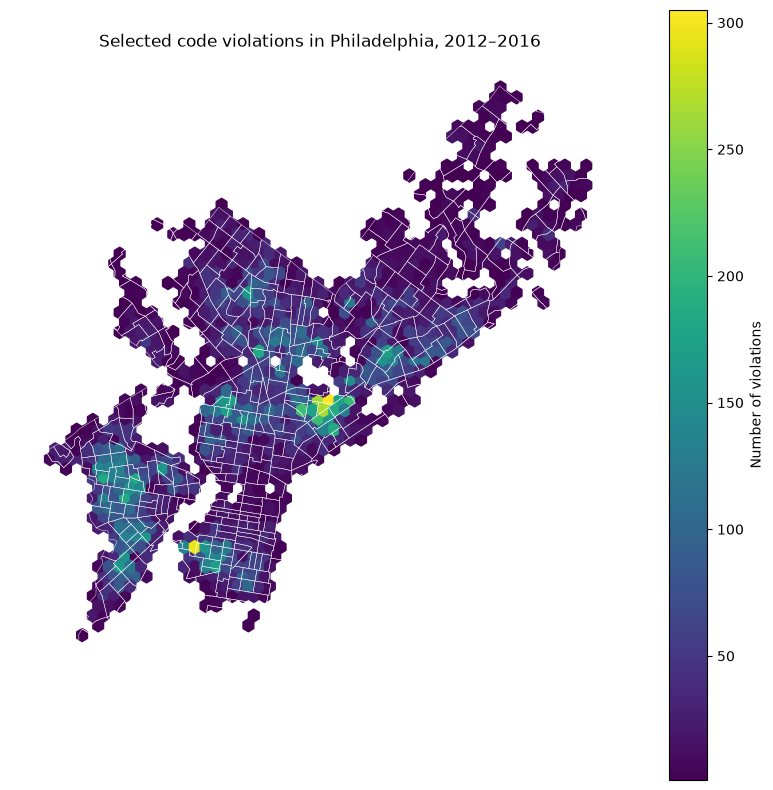

In [22]:
from matplotlib import pyplot as plt

violations_3857 = selected_violations.to_crs(epsg=3857)
tracts_3857 = Philadelphia_tracts[["GEOID", "geometry"]].to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))
hex_vals = ax.hexbin(
    violations_3857.geometry.x,
    violations_3857.geometry.y,
    gridsize=50,
    mincnt=1,
    cmap="viridis",
)
tracts_3857.plot(ax=ax, facecolor="none", edgecolor="white", linewidth=0.3)
fig.colorbar(hex_vals, ax=ax, label="Number of violations")
ax.set_title("Selected code violations in Philadelphia, 2012–2016")
ax.set_axis_off()
ax.set_aspect("equal")
plt.show()


### 1.2.4 Spatially join data sets

To do a census tract comparison to our eviction data, we need to find which census tract each of the code violations falls into. Use the `geopandas.sjoin()` function to do just that. 


**Hints**
- You can re-use your eviction data frame, but you will only need the `geometry` column (specifying census tract polygons) and the `GEOID` column (specifying the name of each census tract).
- Make sure both data frames have the same CRS before joining them together!

In [23]:
violations_with_tract = gpd.sjoin(
    violations_3857,
    tracts_3857,
    predicate="within",
    how="left",
)

print(f"Violations without a matching tract: "
      f"{violations_with_tract['GEOID'].isna().sum():,}")
violations_with_tract.head()


Violations without a matching tract: 0


,lat,lng,violationdescription,geometry,index_right,GEOID
2,40.050593,-75.126578,LICENSE-RES SFD/2FD,POINT (-8363052.408 4873297.042),3185,42101027100
25,40.022406,-75.121872,EXT S-ROOF REPAIR,POINT (-8362528.538 4869198.793),2238,42101028800
30,40.023237,-75.121726,CO DETECTOR NEEDED,POINT (-8362512.286 4869319.592),2238,42101028800
31,40.023397,-75.122241,INT S-CEILING REPAIR/MAINT SAN,POINT (-8362569.615 4869342.851),2238,42101028800
34,40.023773,-75.121603,INT S-FLOOR REPAIR,POINT (-8362498.594 4869397.509),2238,42101028800


### 1.2.5 Calculate the number of violations by type per census tract

Next, we'll want to find the number of violations (for each kind) per census tract. You should group the data frame by violation type and census tract name.

The result of this step should be a data frame with three columns: `violationdescription`, `GEOID`, and `N`, where `N` is the number of violations of that kind in the specified census tract.

**Optional: to make prettier plots**

Some census tracts won't have any violations, and they won't be included when we do the above calculation. However, there is a trick to set the values for those census tracts to be zero. After you calculate the sizes of each violation/census tract group, you can run: 

```python
N = N.unstack(fill_value=0).stack().reset_index(name='N')
```
where `N` gives the total size of each of the groups, specified by violation type and census tract name.

See [this StackOverflow post](https://stackoverflow.com/questions/42854801/including-missing-combinations-of-values-in-a-pandas-groupby-aggregation) for more details.

This part is **optional**, but will make the resulting maps a bit prettier.

In [24]:
N = violations_with_tract.groupby(["violationdescription", "GEOID"]).size()

N = (
    N.unstack(fill_value=0)
    .reindex(index=violation_types, columns=tracts_3857["GEOID"], fill_value=0)
    .stack()
    .reset_index(name="N")
)
N.head()


,violationdescription,GEOID,N
0,INT-PLMBG MAINT FIXTURES-RES,42101000100,0
1,INT-PLMBG MAINT FIXTURES-RES,42101000200,1
2,INT-PLMBG MAINT FIXTURES-RES,42101000300,1
3,INT-PLMBG MAINT FIXTURES-RES,42101000801,0
4,INT-PLMBG MAINT FIXTURES-RES,42101000804,0


### 1.2.6 Merge with census tracts geometries

We now have the number of violations of different types per census tract specified as a regular DataFrame. You can now merge it with the census tract geometries (from your eviction data GeoDataFrame) to create a GeoDataFrame. 

**Hints**
- Use `pandas.merge()` and specify the `on` keyword to be the column holding census tract names. 
- Make sure the result of the merge operation is a GeoDataFrame — you will want the GeoDataFrame holding census tract geometries to be the first argument of the `pandas.merge()` function.

In [25]:
violations_by_tract = pd.merge(
    tracts_3857,
    N,
    on="GEOID",
    how="left",
    validate="one_to_many",
)
violations_by_tract.head()


,GEOID,geometry,violationdescription,N
0,42101000100,"MULTIPOLYGON (((-8364725.429 4859476.459, -836...",INT-PLMBG MAINT FIXTURES-RES,0
1,42101000100,"MULTIPOLYGON (((-8364725.429 4859476.459, -836...",INT S-CEILING REPAIR/MAINT SAN,9
2,42101000100,"MULTIPOLYGON (((-8364725.429 4859476.459, -836...",PLUMBING SYSTEMS-GENERAL,1
3,42101000100,"MULTIPOLYGON (((-8364725.429 4859476.459, -836...",CO DETECTOR NEEDED,0
4,42101000100,"MULTIPOLYGON (((-8364725.429 4859476.459, -836...",INTERIOR SURFACES,0


### 1.2.7 Interactive choropleths for each violation type

Now, we can use `hvplot()` to create an interactive choropleth for each violation type and add a widget to specify different violation types. 

**Hints** 
- You'll need to use the `groupby` keyword to tell `hvplot` to make a series of maps, with a widget to select different violation types.
- You will need to specify `dynamic=False` as a keyword argument to the `hvplot()` function. 
- Be sure to specify a `width` and `height` that makes your output map (roughly) square to limit distortions

In [26]:
violations_map = violations_by_tract.hvplot(
    c="N",
    groupby="violationdescription",
    dynamic=False,
    geo=True,
    crs=3857,
    width=650,
    height=650,
    cmap="viridis",
    clim=(0, violations_by_tract["N"].max()),
    colorbar=True,
    clabel="Number of violations",
    hover_cols=["GEOID"],
    title="Code violations by census tract, 2012–2016",
    widget_location="top",
)
violations_map


ModuleNotFoundError: No module named 'jupyter_bokeh'

Column
    [0] WidgetBox(align=('center', 'start'))
        [0] Select(label='violationdescription', name='violationdescription', options=['CO DETECTOR NEEDED', ...], value='CO DETECTOR NEEDED')
    [1] HoloViews(HoloMap, widget_location='top')

## 1.3. A side-by-side comparison

From the interactive maps of evictions and violations, you should notice a lot of spatial overlap. 

As a final step, we'll make a side-by-side comparison to better show the spatial correlations. This will involve a few steps: 

1. Trim the evictions data frame plotted in section 1.1.5 to only include evictions from 2016. 
2. Trim the L+I violations data frame plotted in section 1.2.7 to only include a single violation type (pick whichever one you want!).
3. Use `hvplot()` to make two interactive choropleth maps, one for the data from step 1. and one for the data in step 2.
4. Show these two plots side by side (one row and 2 columns) using the syntax for combining charts.

**Note:** since we selected a single year and violation type, you won't need to use the `groupby=` keyword here.

In [27]:
# Select one year and one of the assigned violation types.
evictions_2016 = evictions_3857.loc[evictions_3857["variable"] == "e-16"]
selected_type = "INT-PLMBG MAINT FIXTURES-RES"
violations_comparison = violations_by_tract.loc[
    violations_by_tract["violationdescription"] == selected_type
]

evictions_plot = evictions_2016.hvplot(
    c="evictions",
    geo=True,
    crs=3857,
    width=500,
    height=500,
    cmap="viridis",
    clim=(0, evictions_2016["evictions"].max()),
    colorbar=True,
    clabel="Evictions (2016)",
    hover_cols=["GEOID"],
    title="Evictions, 2016",
)
violations_plot = violations_comparison.hvplot(
    c="N",
    geo=True,
    crs=3857,
    width=500,
    height=500,
    cmap="viridis",
    clim=(0, violations_comparison["N"].max()),
    colorbar=True,
    clabel="Violations (2012–2016)",
    hover_cols=["GEOID", "violationdescription"],
    title=f"{selected_type}, 2012–2016",
)

comparison = (evictions_plot + violations_plot).cols(2)
comparison


:Layout
   .Polygons.I  :Polygons   [Longitude,Latitude]   (evictions,GEOID)
   .Polygons.II :Polygons   [Longitude,Latitude]   (N,GEOID,violationdescription)

## 1.4. Extra Credit

Identify the 20 most common types of violations within the time period of 2012 to 2016 and create a set of interactive choropleths similar to what was done in section 1.2.7. 

Use this set of maps to identify 3 types of violations that don't seem to have much spatial overlap with the number of evictions in the City.

In [28]:
top20_counts = (
    violations.groupby("violationdescription").size()
    .sort_values(ascending=False).head(20).rename("total_violations")
)
top20_types = top20_counts.index.tolist()
top20_counts.to_frame()


,total_violations
violationdescription,
CLIP VIOLATION NOTICE,64811
EXT A-VACANT LOT CLEAN/MAINTAI,32633
HIGH WEEDS-CUT,20504
LICENSE-VAC RES BLDG,15278
VACANT PROP STANDARD,12283
RUBBISH/GARBAGE EXTERIOR-OWNER,11416
EXT A-CLEAN RUBBISH/GARBAGE,8832
LICENSE-RES SFD/2FD,8179
EXT A-CLEAN WEEDS/PLANTS,7904


In [29]:
top20_points = violations.loc[
    violations["violationdescription"].isin(top20_types)
].to_crs(epsg=3857)
top20_joined = gpd.sjoin(
    top20_points, tracts_3857, predicate="within", how="left"
)
top20_N = (
    top20_joined.groupby(["violationdescription", "GEOID"]).size()
    .unstack(fill_value=0)
    .reindex(index=top20_types, columns=tracts_3857["GEOID"], fill_value=0)
    .stack().reset_index(name="N")
)
top20_by_tract = pd.merge(
    tracts_3857, top20_N, on="GEOID", validate="one_to_many"
)
top20_map = top20_by_tract.hvplot(
    c="N", groupby="violationdescription", dynamic=False,
    geo=True, crs=3857, width=650, height=650,
    cmap="viridis", colorbar=True, clabel="Number of violations",
    hover_cols=["GEOID"], widget_location="top",
    clim=(0, top20_by_tract["N"].max()),
    title="20 most common violation types, 2012-2016",
)
top20_map


ModuleNotFoundError: No module named 'jupyter_bokeh'

Column
    [0] WidgetBox(align=('center', 'start'))
        [0] Select(label='violationdescription', name='violationdescription', options=['ANNUAL CERT FIRE ALARM',...], value='ANNUAL CERT FIRE ALARM')
    [1] HoloViews(HoloMap, widget_location='top')

In [30]:
# Supplement the visual comparison with Pearson correlations of tract counts.
top20_wide = top20_N.pivot(index="GEOID", columns="violationdescription", values="N")
evictions_reference = evictions_2016.set_index("GEOID")["evictions"]
correlations = top20_wide.corrwith(evictions_reference).rename("Pearson_r")
correlation_table = top20_counts.to_frame().join(correlations).sort_values("Pearson_r")
correlation_table


,total_violations,Pearson_r
violationdescription,,
VIOL C&I MESSAGE,5031,-0.126517
LICENSE-RES GENERAL,7682,0.156765
EXT A-VACANT LOT CLEAN/MAINTAI,32633,0.209211
LICENSE - RENTAL PROPERTY,4226,0.216711
RUBBISH/GARBAGE EXTERIOR-OWNER,11416,0.220029
HIGH WEEDS-CUT,20504,0.222780
ANNUAL CERT FIRE ALARM,4611,0.335786
CLIP VIOLATION NOTICE,64811,0.339676
VAC PROP REPLAC WIN/DRS 80%,4147,0.378311


In [31]:

low_overlap_types = [
    "VIOL C&I MESSAGE",
    "LICENSE-RES GENERAL",
    "EXT A-VACANT LOT CLEAN/MAINTAI",
]
low_overlap_plots = []
for violation_type in low_overlap_types:
    subset = top20_by_tract.loc[
        top20_by_tract["violationdescription"] == violation_type
    ]
    low_overlap_plots.append(subset.hvplot(
        c="N", geo=True, crs=3857, width=500, height=500,
        cmap="viridis", colorbar=True, clabel="Violations (2012-2016)",
        clim=(0, subset["N"].max()), hover_cols=["GEOID"],
        title=violation_type,
    ))
low_overlap_comparison = (
    evictions_plot + low_overlap_plots[0]
    + low_overlap_plots[1] + low_overlap_plots[2]
).cols(2)
low_overlap_comparison


:Layout
   .Polygons.I   :Polygons   [Longitude,Latitude]   (evictions,GEOID)
   .Polygons.II  :Polygons   [Longitude,Latitude]   (N,GEOID)
   .Polygons.III :Polygons   [Longitude,Latitude]   (N,GEOID)
   .Polygons.IV  :Polygons   [Longitude,Latitude]   (N,GEOID)

## Part 2: Exploring the NDVI in Philadelphia

In this part, we'll explore the NDVI in Philadelphia a bit more. This part will include two parts:

1. We'll compare the median NDVI within the city limits and the immediate suburbs
1. We'll calculate the  NDVI around street trees in the city.

## 2.1 Comparing the NDVI in the city and the suburbs

### 2.1.1 Load Landsat data for Philadelphia

Use rasterio to load the landsat data for Philadelphia (available in the "data/" folder)

In [32]:
import rasterio

landsat = rasterio.open("data/landsat8_philly.tif")

### 2.1.2 Separating the city from the suburbs

Create two polygon objects, one for the city limits and one for the suburbs. To calculate the suburbs polygon, we will take everything outside the city limits but still within the bounding box. 

* The city limits are available in the "data/" folder.
* To calculate the suburbs polygon, the "envelope" attribute of the city limits geometry will be useful.
* You can use geopandas' [geometric manipulation](https://geopandas.org/en/stable/docs/user_guide/geometric_manipulations.html) functionality to calculate the suburbs polygon from the city limits polygon and the envelope polygon.

In [33]:
city_limits = gpd.read_file("data/City_Limits.geojson").to_crs(epsg=landsat.crs.to_epsg())
outer_box = city_limits.geometry.envelope
suburbs = outer_box.difference(city_limits.geometry)


### 2.1.3 Mask and calculate the NDVI for the city and the suburbs

Using the two polygons from the last section, use rasterio's mask functionality to create two masked arrays from the landsat data, one for the city and one for the suburbs. 

For each masked array, calculate the NDVI.

In [34]:
from rasterio.mask import mask
city_image, city_transform = mask(
    landsat, city_limits.geometry, crop=True, filled=False
)

suburbs_image, suburbs_transform = mask(
    landsat, suburbs, crop=True, filled=False
)

city_red = city_image[3].astype(float)
city_nir = city_image[4].astype(float)

suburbs_red = suburbs_image[3].astype(float)
suburbs_nir = suburbs_image[4].astype(float)

city_sum = np.ma.masked_equal(city_nir + city_red, 0)
suburbs_sum = np.ma.masked_equal(suburbs_nir + suburbs_red, 0)

city_ndvi = ((city_nir - city_red) / city_sum).filled(np.nan)
suburbs_ndvi = ((suburbs_nir - suburbs_red) / suburbs_sum).filled(np.nan)

### 2.1.4 Calculate the median NDVI within the city and within the suburbs

* Calculate the median value from your NDVI arrays for the city and suburbs
* Numpy's `nanmedian` function will be useful for ignoring NaN elements
* Print out the median values. Which has a higher NDVI: the city or suburbs?

In [35]:
print("City median NDVI:", np.nanmedian(city_ndvi))
print("Suburbs median NDVI:", np.nanmedian(suburbs_ndvi))

City median NDVI: 0.20246571107834677
Suburbs median NDVI: 0.3748493370831659


## 2.2 Calculating the NDVI for Philadelphia's street treets

### 2.2.1 Load the street tree data

The data is available in the "data/" folder. It has been downloaded from [OpenDataPhilly](https://www.opendataphilly.org/dataset/ppr-tree-canopy). It contains the locations of abot 2,500 street trees in Philadelphia.

In [36]:
street_tree = gpd.read_file("data/ppr_tree_canopy_points_2015.geojson").to_crs(epsg=landsat.crs.to_epsg())

### 2.2.2 Calculate the NDVI values at the locations of the street trees

* Use the rasterstats package to calculate the NDVI values at the locations of the street trees.
* Since these are point geometries, you can calculate either the median or the mean statistic (only one pixel will contain each point).

In [37]:
from rasterstats import zonal_stats
trees = street_tree.to_crs(epsg=landsat.crs.to_epsg())

tree_stats = zonal_stats(
trees, 
 city_ndvi,
 affine=city_transform,
 stats=["mean"],
 nodata=np.nan
)

trees["NDVI"] = [result["mean"] for result in tree_stats]


### 2.2.3 Plotting the results

Make two plots of the results:

1. A histogram of the NDVI values, using matplotlib's `hist` function. Include a vertical line that marks the NDVI = 0 threshold
1. A plot of the street tree points, colored by the NDVI value, using geopandas' `plot` function. Include the city limits boundary on your plot.

The figures should be clear and well-styled, with for example, labels for axes, legends, and clear color choices. 

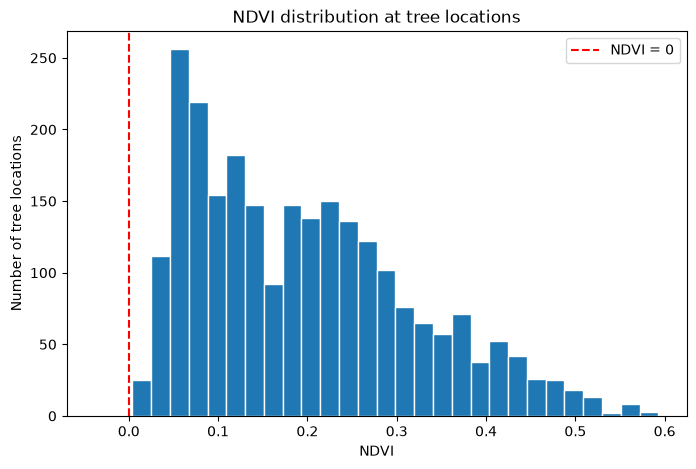

In [38]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(trees["NDVI"].dropna(), bins=30, edgecolor="white")
ax.axvline(0, color="red", linestyle="--", label="NDVI = 0")

ax.set_xlabel("NDVI")
ax.set_ylabel("Number of tree locations")
ax.set_title("NDVI distribution at tree locations")
ax.legend()
plt.show()

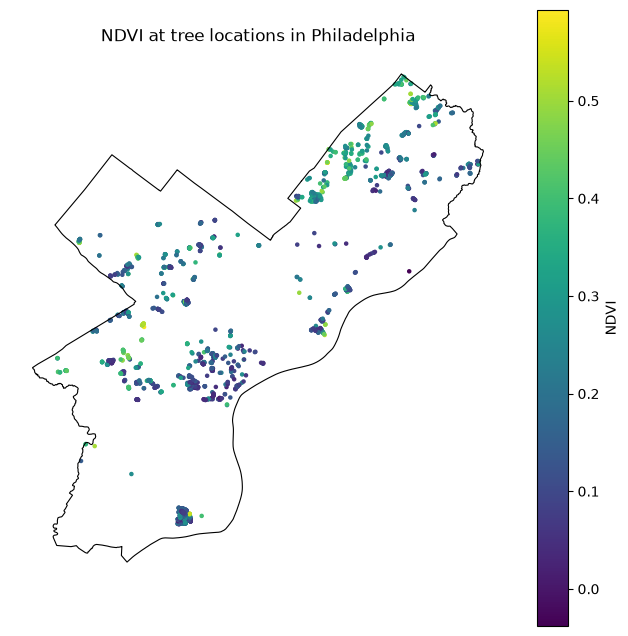

In [39]:
fig, ax = plt.subplots(figsize=(8, 8))

city_limits.to_crs(trees.crs).boundary.plot(
    ax=ax, color="black", linewidth=0.8
)

trees.plot(
    ax=ax,
    column="NDVI",
    cmap="viridis",
    markersize=5,
    legend=True,
    legend_kwds={"label": "NDVI"},
)

ax.set_title("NDVI at tree locations in Philadelphia")
ax.set_axis_off()
plt.show()